# Hex Analysis: Heatmaps and Connectivity

This notebook demonstrates two analysis functions from `hextraj`:

- **`hex_counts`** — aggregate trajectory observations into a spatial heatmap, counting how many times each hex cell was visited across a dataset.
- **`hex_connectivity`** — build a start-to-end connectivity matrix that records how many trajectories travelled from each origin hex to each destination hex.

Both functions operate on `xr.DataArray` objects of integer hex IDs produced by `HexProj.label()`. They return `GeoDataFrame` objects, which carry geometry alongside statistics and integrate directly with geopandas and matplotlib for visualisation.

The dataset used here is the bundled NW European Shelf trajectory dataset: 5 000 Lagrangian particles advected for 20 observations (roughly three weeks) in May–June 2019.


## Setup

In [1]:
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.io.shapereader as shpreader
from importlib.resources import files

from hextraj import HexProj, hex_counts, hex_connectivity
from hextraj.hex_id import INVALID_HEX_ID

In [2]:
coastlines = gpd.read_file(
    shpreader.natural_earth(resolution="10m", category="physical", name="coastline")
)

## Load the NW Shelf trajectory data

The dataset contains 5 000 Lagrangian particle trajectories released on the NW European Shelf. Each trajectory has 20 observation steps separated by daily snapshots, covering May–June 2019. Dimensions are `(traj, obs)`.

The variables of interest are `lon` and `lat` (particle positions), plus `temperature` and `salinity` at each position. Positions where a particle has left the simulation domain are stored as `NaN`.

In [3]:
p = files("hextraj.data.trajs").joinpath("nwshelf.nc")
ds = xr.open_dataset(p)
ds

<xarray.Dataset> Size: 4MB
Dimensions:      (traj: 5000, obs: 20)
Dimensions without coordinates: traj, obs
Data variables:
    time         (traj, obs) datetime64[ns] 800kB ...
    trajectory   (traj, obs) float64 800kB ...
    lon          (traj, obs) float32 400kB ...
    lat          (traj, obs) float32 400kB ...
    z            (traj, obs) float32 400kB ...
    temperature  (traj, obs) float32 400kB ...
    salinity     (traj, obs) float32 400kB ...
    land         (traj, obs) float32 400kB ...
Attributes:
    feature_type:           trajectory
    Conventions:            CF-1.6/CF-1.7
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_version:        2.3.1
    parcels_mesh:           spherical

## Build a HexProj for the NW Shelf domain

The NW Shelf domain spans roughly 46–63 °N and 16 °W–10 °E. A Lambert Azimuthal Equal-Area projection centred near the domain midpoint (−3 °E, 54 °N) minimises distortion across the region.

A hex size of 100 km (corner-to-centre distance) gives a coarse but meaningful spatial resolution — each hexagon covers roughly 26 000 km². Larger sizes produce a sparser grid with higher counts per cell; smaller sizes resolve more spatial detail but require more data to populate.

In [4]:
hp = HexProj(
    projection_name="laea",
    lon_origin=-3.0,
    lat_origin=54.0,
    hex_size_meters=100_000,
    hex_orientation="flat",
)
hp

HexProj(projection_name='laea', lon_origin=-3.0, lat_origin=54.0, hex_size_meters=100000, hex_orientation='flat', )

Label every `(traj, obs)` position with its hex ID. `NaN` positions (particles that have left the domain) are assigned `INVALID_HEX_ID = -1` by `hp.label()`.

In [5]:
hex_ids = xr.DataArray(
    hp.label(ds.lon.values, ds.lat.values),
    dims=["traj", "obs"],
)
hex_ids

/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)


<xarray.DataArray (traj: 5000, obs: 20)> Size: 800kB
array([[245, 245, 245, ..., 245, 245, 245],
       [ 20,  20,  20, ...,  20,  20,  20],
       [126, 126, 126, ...,  97,  97,  97],
       ...,
       [ 48,  48,  48, ...,  48,  48,  48],
       [ 29,  29,  29, ...,  29,  29,  29],
       [ 76,  76,  76, ...,  76,  76,  76]], shape=(5000, 20))
Dimensions without coordinates: traj, obs

## Hex heatmap: `hex_counts`

`hex_counts` answers the question: *how many trajectory observations fell in each hex cell, summing over a chosen set of dimensions?*

Formally, let $\mathbf{H}$ be the hex ID tensor indexed by $(k, r)$ where $k$ are "keep" indices and $r$ are "reduce" indices. Define the indicator

$$X_h(k, r) = \begin{cases} 1 & \text{if } H(k,r) = h \\ 0 & \text{otherwise,} \end{cases}$$

then the count for hex $h$ at keep-index $k$ is

$$C(k, h) = \sum_{r \in \mathcal{R}} X_h(k, r).$$

The result is a `GeoDataFrame` indexed by `hex_id`, with columns `count` and `geometry` (a hexagonal polygon in EPSG:4326). Hex IDs that were never observed are absent. The special bucket `INVALID_HEX_ID = -1` captures all out-of-domain positions and is included in the result with `geometry = None`.

Reduce over both `traj` and `obs` to get the total visit count per hex across all trajectories and all time steps.

In [6]:
counts = hex_counts(hex_ids, reduce_dims=["traj", "obs"], hp=hp)
counts

,count,geometry
hex_id,,
245,1211,"POLYGON ((-12.39371 61.47694, -13.07512 60.644..."
20,1046,"POLYGON ((-1.62545 49.32008, -2.32348 48.54713..."
126,808,"POLYGON ((-13.0375 54.36364, -13.60061 53.5297..."
97,1336,"POLYGON ((-10.89098 55.30492, -11.50841 54.480..."
128,1174,"POLYGON ((-11.21268 56.84929, -11.8452 56.0235..."
...,...,...
17,54,"POLYGON ((-6.04815 53.96142, -6.7397 53.16285,..."
73,21,"POLYGON ((2.48928 49.19153, 1.72975 48.44607, ..."
85,40,"POLYGON ((-7.45583 45.33128, -8.01956 44.52226..."


The `INVALID_HEX_ID` row (index value `−1`) has `geometry = None` and records the total number of observations where the particle had left the domain. Inspect it separately, then drop it before plotting.

In [7]:
print("INVALID_HEX_ID row:")
print(counts.loc[INVALID_HEX_ID])
print()
print(f"Out-of-domain observations: {counts.loc[INVALID_HEX_ID, 'count']}")
print(f"Total observations: {counts['count'].sum()}")

INVALID_HEX_ID row:
count       2915
geometry    None
Name: -1, dtype: object

Out-of-domain observations: 2915
Total observations: 100000


Drop the invalid row and plot the heatmap. Each polygon is coloured by its total visit count.

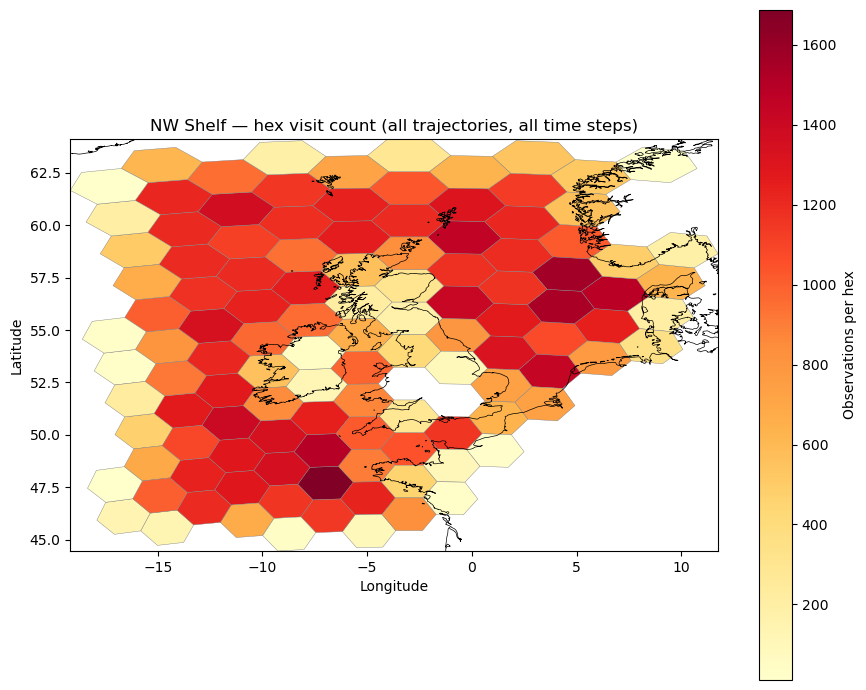

In [8]:
counts_valid = counts.drop(index=INVALID_HEX_ID, errors="ignore")

fig, ax = plt.subplots(figsize=(9, 7))
counts_valid.plot(
    column="count",
    ax=ax,
    legend=True,
    legend_kwds={"label": "Observations per hex", "orientation": "vertical"},
    cmap="YlOrRd",
    edgecolor="grey",
    linewidth=0.3,
)
coastlines.plot(ax=ax, color="black", linewidth=0.5)
ax.set_xlim(counts_valid.total_bounds[[0, 2]])
ax.set_ylim(counts_valid.total_bounds[[1, 3]])
ax.set_title("NW Shelf — hex visit count (all trajectories, all time steps)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Connectivity: `hex_connectivity`

`hex_connectivity` answers the question: *how many trajectories started in hex $h_0$ and ended in hex $h_1$?*

Select the release position with `from_dim="obs", from_idx=0` and the final position with `to_dim="obs", to_idx=-1`. For each trajectory the function extracts a (start hex, end hex) pair and counts how many trajectories share each unique pair:

$$C(h_0, h_1) = \text{count}\bigl(\text{start} = h_0,\ \text{end} = h_1\bigr).$$

The result is a `GeoDataFrame` with a `(from_id, to_id)` MultiIndex and a `count` column. Trajectories that exit the simulation domain arrive at `INVALID_HEX_ID = -1` as their destination — these pairs are preserved in the result and treated as domain export.

In [9]:
conn = hex_connectivity(
    hex_ids,
    from_dim="obs", from_idx=0,
    to_dim="obs",   to_idx=-1,
    hp=hp,
)
conn

,,count,geometry
from_id,to_id,,
245,245,32.0,"LINESTRING (-14.24247 61.34352, -14.24247 61.3..."
20,20,42.0,"LINESTRING (-3 49.32867, -3 49.32867)"
126,97,9.0,"LINESTRING (-14.55786 54.22724, -12.4529 55.19..."
29,46,8.0,"LINESTRING (3.97182 54.57889, 6.4529 55.19494)"
113,-1,12.0,None
...,...,...,...
32,19,1.0,"LINESTRING (-7.74654 55.46543, -5.42356 56.31078)"
22,37,1.0,"LINESTRING (-9.27304 49.93108, -11.21625 49.02..."
108,106,1.0,"LINESTRING (-14.55264 45.5639, -16.6378 46.09891)"


Inspect the ten most common start-to-end connectivity pairs.

In [10]:
conn.nlargest(10, "count")[["count"]]

,,count
from_id,to_id,
21,21,58.0
24,24,57.0
22,22,54.0
12,12,53.0
10,10,52.0
28,28,51.0
63,63,50.0
42,42,48.0
48,48,47.0


### Forward connectivity heatmaps

Pick four starting hexes that each launch the most trajectories — identified as the four `from_id` values with the highest marginal count. For each starting hex, plot the distribution of where its trajectories end up as a choropleth over the hex grid.

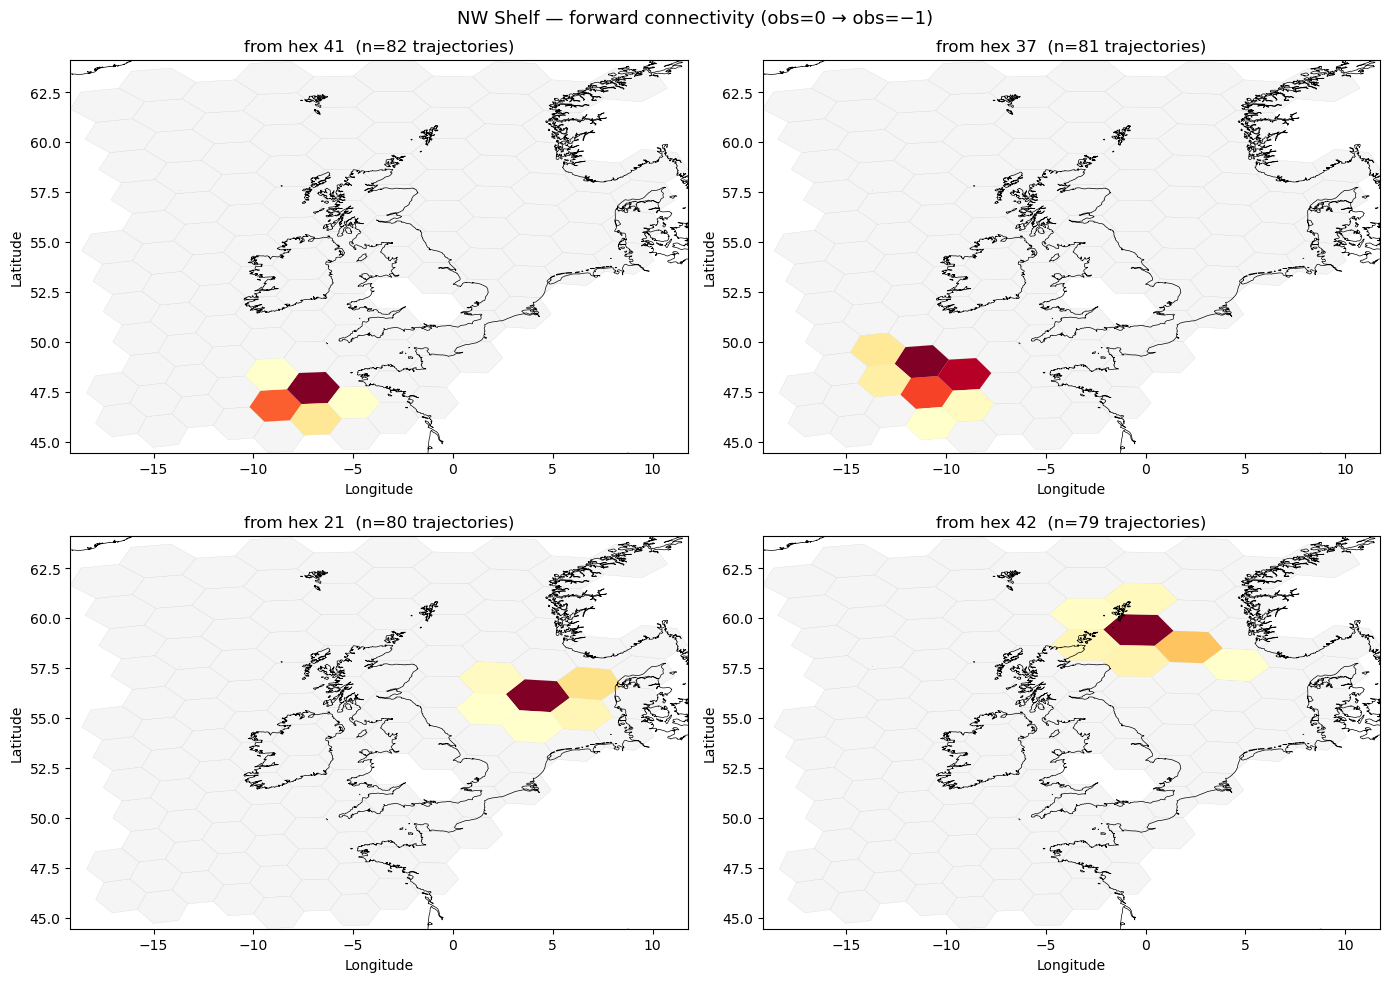

In [11]:
marginal = conn["count"].groupby(level="from_id").sum()
top4 = marginal.drop(index=INVALID_HEX_ID, errors="ignore").nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, from_hex in zip(axes.flat, top4):
    dest = conn.loc[(from_hex, slice(None))]
    dest = dest[dest.index != INVALID_HEX_ID]
    dest_gdf = gpd.GeoDataFrame(
        dest[["count"]].join(counts_valid[["geometry"]], how="left"),
        geometry="geometry",
        crs="EPSG:4326",
    ).dropna(subset=["geometry"])

    counts_valid.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.2)
    dest_gdf.plot(column="count", ax=ax, cmap="YlOrRd", edgecolor="none", legend=False)
    coastlines.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_xlim(counts_valid.total_bounds[[0, 2]])
    ax.set_ylim(counts_valid.total_bounds[[1, 3]])
    ax.set_title(f"from hex {from_hex}  (n={int(marginal[from_hex])} trajectories)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle("NW Shelf — forward connectivity (obs=0 → obs=−1)", fontsize=13)
plt.tight_layout()
plt.show()

## INVALID_HEX_ID as a domain-exit signal

In a well-run simulation, a particle becomes invalid when it exits the region covered by the circulation data — its lon/lat is set to `NaN` by the advection code. The connectivity entry `(h, INVALID_HEX_ID)` therefore records *domain export*: how many trajectories that started in hex $h$ eventually left the simulation area.

Filter the connectivity matrix to isolate these domain-exit pairs and inspect which starting hexes contribute most particles to the out-of-domain bucket.

In [12]:
domain_exits = conn.xs(INVALID_HEX_ID, level="to_id")
domain_exits_sorted = domain_exits.sort_values("count", ascending=False)
print(f"Hex cells that export particles out of domain: {len(domain_exits_sorted)}")
domain_exits_sorted.head(10)[["count"]]

Hex cells that export particles out of domain: 30


,count
from_id,
66,39.0
161,24.0
93,19.0
126,16.0
243,14.0
290,14.0
113,12.0
79,12.0
86,12.0


Map the domain-exit counts as a heatmap. After `.xs()` the index is `from_id` (source hex), but the geometry column still contains `None` (it was a LineString to `INVALID_HEX_ID`). Re-attach hex polygon geometries by joining on the source hex ID before plotting. Darker hexes are the primary source regions for particles that leave the NW Shelf simulation domain.

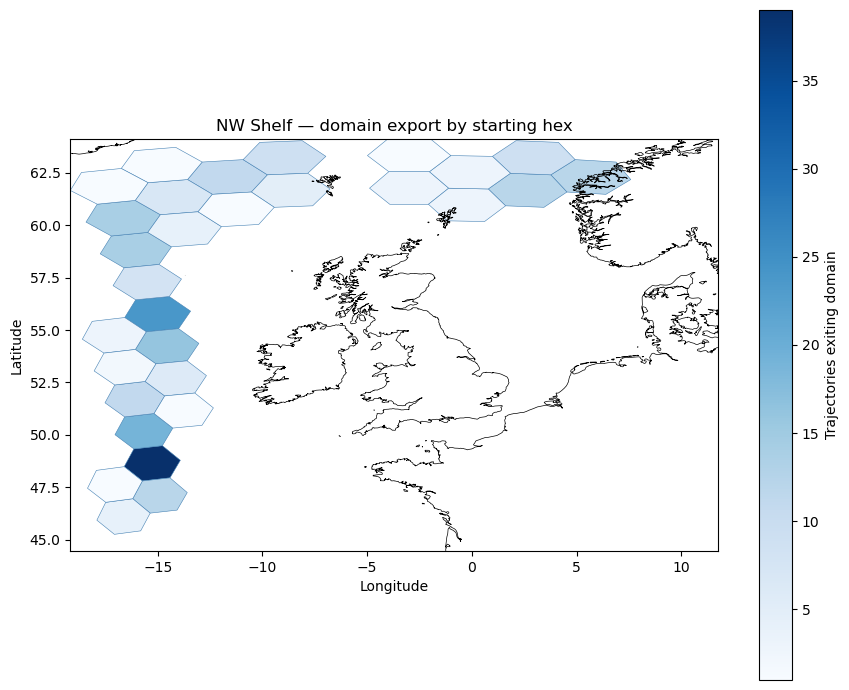

In [13]:
exit_gdf = gpd.GeoDataFrame(
    domain_exits_sorted[["count"]].join(counts[["geometry"]], how="left"),
    geometry="geometry",
    crs="EPSG:4326",
).dropna(subset=["geometry"])

fig, ax = plt.subplots(figsize=(9, 7))
exit_gdf.plot(
    column="count",
    ax=ax,
    legend=True,
    legend_kwds={"label": "Trajectories exiting domain", "orientation": "vertical"},
    cmap="Blues",
    edgecolor="steelblue",
    linewidth=0.4,
)
coastlines.plot(ax=ax, color="black", linewidth=0.5)
ax.set_xlim(counts_valid.total_bounds[[0, 2]])
ax.set_ylim(counts_valid.total_bounds[[1, 3]])
ax.set_title("NW Shelf — domain export by starting hex")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Normalisation: conditional transport probability

The raw connectivity $C(h_0, h_1)$ is a joint count. Dividing by the total number of trajectories that started in each hex $h_0$ gives the conditional probability of reaching destination $h_1$:

$$P(\text{end} = h_1 \mid \text{start} = h_0) = \frac{C(h_0, h_1)}{\displaystyle\sum_{h_1'} C(h_0, h_1')}.$$

The denominator is the marginal count of all trajectories starting in $h_0$ — including those that exited the domain (counted in the `INVALID_HEX_ID` bucket). This ensures that probabilities sum to exactly 1 for every starting hex, with no information discarded.

Compute the marginal counts by summing over `to_id` within each `from_id` group, then divide.

In [14]:
marginal = conn["count"].groupby(level="from_id").transform("sum")
conn["prob"] = conn["count"] / marginal

Verify that the conditional probabilities sum to 1 for each starting hex (up to floating-point rounding).

In [15]:
prob_sums = conn["prob"].groupby(level="from_id").sum()
print("Min probability sum:", prob_sums.min())
print("Max probability sum:", prob_sums.max())

Min probability sum: 0.9999999999999999
Max probability sum: 1.0000000000000002


Plot the in-domain conditional transport probability. Thicker, brighter edges indicate more probable connections. Only pairs where both endpoints are in-domain are shown.

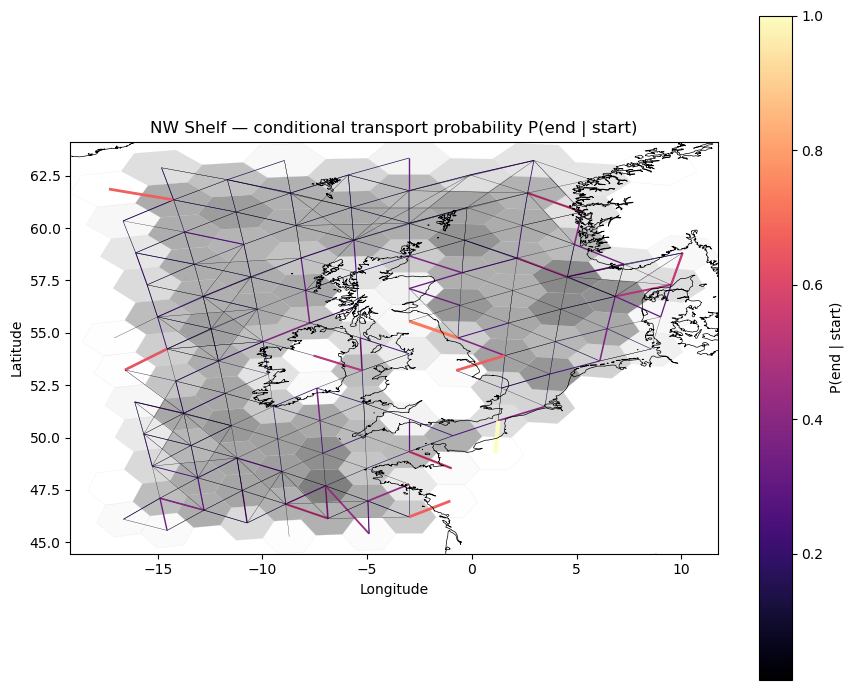

In [16]:
conn_prob_valid = conn[conn.geometry.notna()]

fig, ax = plt.subplots(figsize=(9, 7))

counts_valid.plot(
    column="count",
    ax=ax,
    cmap="Greys",
    edgecolor="lightgrey",
    linewidth=0.2,
    alpha=0.5,
    legend=False,
)

max_prob = conn_prob_valid["prob"].max()
conn_prob_valid.plot(
    column="prob",
    ax=ax,
    cmap="magma",
    linewidth=(conn_prob_valid["prob"] / max_prob * 3).clip(lower=0.2),
    legend=True,
    legend_kwds={"label": "P(end | start)", "orientation": "vertical"},
)

coastlines.plot(ax=ax, color="black", linewidth=0.5)
ax.set_xlim(counts_valid.total_bounds[[0, 2]])
ax.set_ylim(counts_valid.total_bounds[[1, 3]])
ax.set_title("NW Shelf — conditional transport probability P(end | start)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Multi-generation connectivity: `hex_connectivity_power`

The `conn` GeoDataFrame built above represents one generation of drift: each row encodes how many trajectories moved from a starting hex to an ending hex over a single observation period.

Raising this connectivity to the power $n$ asks: *if the same drift pattern repeated itself $n$ times, where would a particle released from hex $h_i$ end up?* Formally, the $n$-generation transfer matrix $T^{(n)}$ is defined by

$$T^{(n)}_{ij} = (T^n)_{ij} = P\!\bigl(\text{arrive at } h_j \text{ after } n \text{ generations} \mid \text{depart from } h_i\bigr),$$

where $T_{ij}$ is first obtained by row-normalising the raw counts $C(h_i, h_j)$.

`INVALID_HEX_ID` acts as an **absorbing state** by default: once a particle leaves the domain it stays out, so probability mass that flows into INVALID accumulates there over successive generations. Passing `condition_on_valid=True` instead zeros the INVALID column and renormalises, giving the conditional distribution over *in-domain* destinations for particles that remain in the domain for all $n$ steps.

In [17]:
from hextraj import hex_connectivity_power

In [18]:
conn2 = hex_connectivity_power(conn, n=2, hp=hp)
conn4 = hex_connectivity_power(conn, n=4, hp=hp)

Each row of the output should sum to 1: each starting hex's probability mass is fully accounted for, either at a valid destination or at `INVALID_HEX_ID`.

In [19]:
prob_sums = conn2["probability"].groupby(level="from_id").sum()
print(prob_sums.describe())

count    116.000000
mean       0.999631
std        0.003979
min        0.957143
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: probability, dtype: float64


### Forward probability maps across time horizons

The four panels below show where hex 38 (approximately 4°E, 57°N — central North Sea) sends its particles after 1, 2, 4, and 8 generations of the same drift pattern. As $n$ increases, probability spreads over a wider area and accumulates in `INVALID_HEX_ID` (not shown) for particles that have exited the domain.

In [20]:
conn8 = hex_connectivity_power(conn, n=8, hp=hp)

conn1_prob = conn.copy()
marginal_from = conn1_prob["count"].groupby(level="from_id").transform("sum")
conn1_prob["probability"] = conn1_prob["count"] / marginal_from

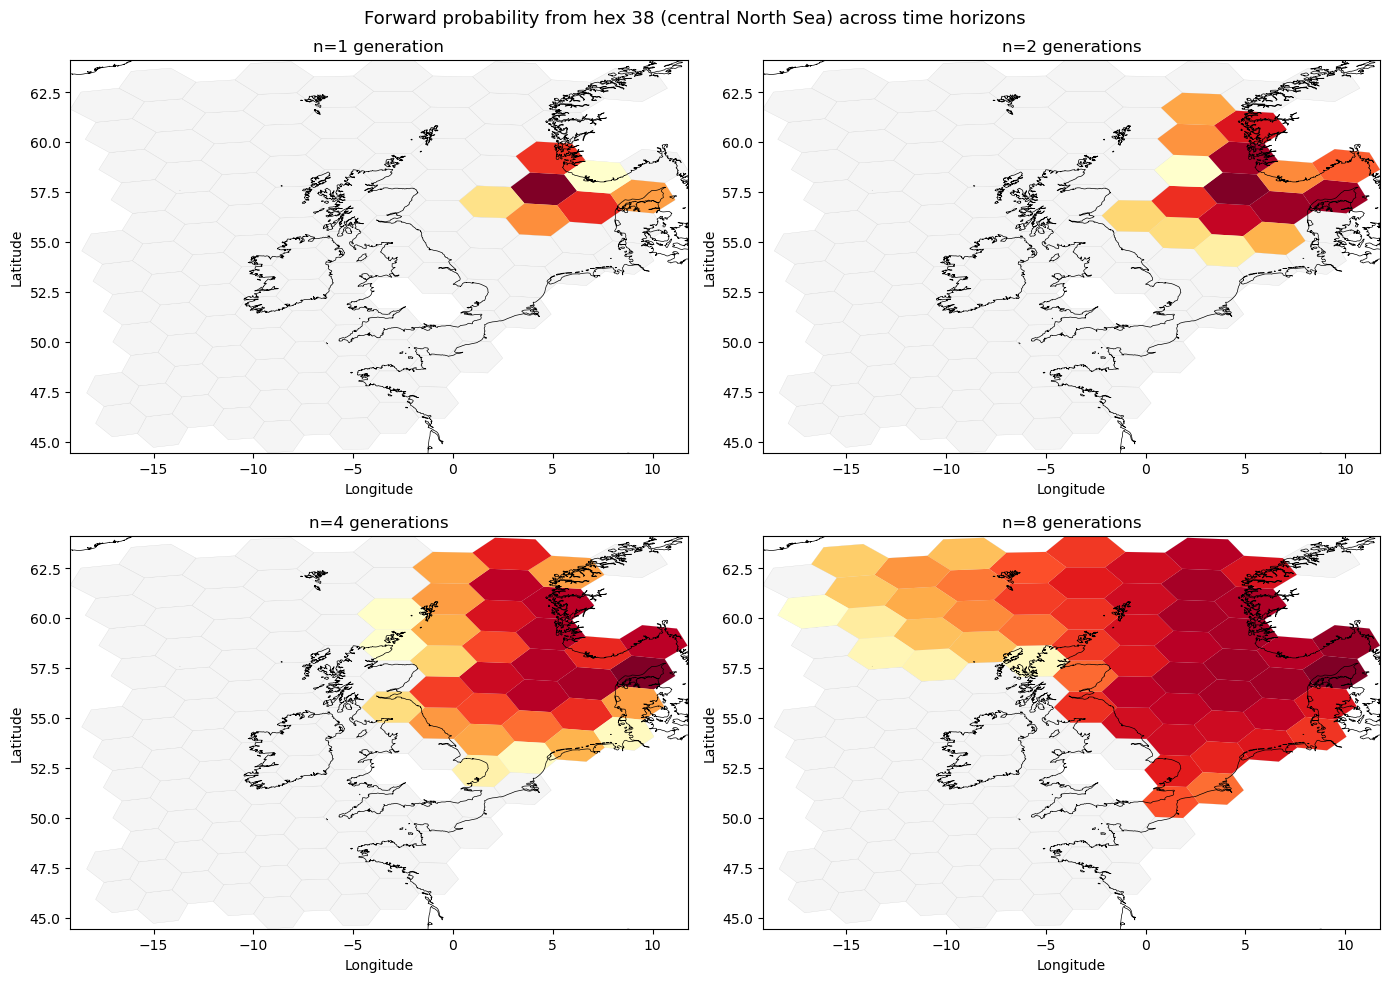

In [21]:
from matplotlib.colors import LogNorm

from_hex = 38

generations = [(1, conn1_prob), (2, conn2), (4, conn4), (8, conn8)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (n, conn_n) in zip(axes.flat, generations):
    dest = conn_n.loc[(from_hex, slice(None))]
    dest = dest[dest.index != INVALID_HEX_ID]
    dest_gdf = gpd.GeoDataFrame(
        dest[["probability"]].join(counts_valid[["geometry"]], how="left"),
        geometry="geometry",
        crs="EPSG:4326",
    ).dropna(subset=["geometry"])

    counts_valid.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.2)
    if len(dest_gdf) > 0:
        vmin = dest_gdf["probability"][dest_gdf["probability"] > 0].min()
        vmax = dest_gdf["probability"].max()
        dest_gdf.plot(
            column="probability", ax=ax, cmap="YlOrRd", edgecolor="none",
            norm=LogNorm(vmin=vmin, vmax=vmax), legend=False,
        )
    coastlines.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_xlim(counts_valid.total_bounds[[0, 2]])
    ax.set_ylim(counts_valid.total_bounds[[1, 3]])
    ax.set_title(f"n={n} generation{'s' if n > 1 else ''}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle(f"Forward probability from hex {from_hex} (central North Sea) across time horizons", fontsize=13)
plt.tight_layout()
plt.show()

### Conditioning on staying in-domain: `condition_on_valid`

The two panels below compare the 4-generation probability distribution for the same starting hex under the two INVALID treatments:

- **Left (`condition_on_valid=False`)**: INVALID is an absorbing state. Probability mass that has drained to INVALID is absent from the map — the hex colours show only the fraction of particles still in-domain, so the distribution sums to less than 1 over valid hexes.
- **Right (`condition_on_valid=True`)**: INVALID is removed before computing $T^4$, and each row is renormalised. The distribution conditions on the particle remaining in-domain for all 4 steps, so the colours sum to 1 over valid hexes. This reveals the *relative* spread among in-domain destinations independently of how many particles have left.

In [22]:
conn4_absorb = hex_connectivity_power(conn, n=4, hp=hp, condition_on_valid=False)
conn4_cond = hex_connectivity_power(conn, n=4, hp=hp, condition_on_valid=True)

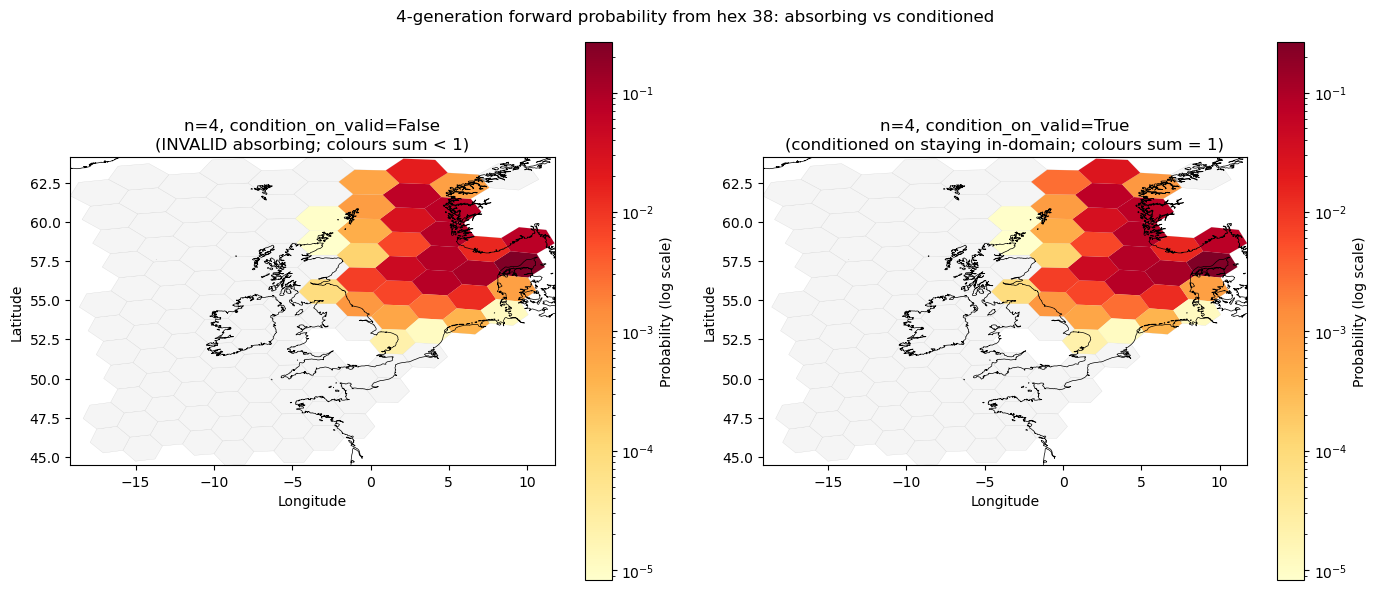

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (conn4_absorb, "n=4, condition_on_valid=False\n(INVALID absorbing; colours sum < 1)"),
    (conn4_cond,   "n=4, condition_on_valid=True\n(conditioned on staying in-domain; colours sum = 1)"),
]

for ax, (conn_n, title) in zip(axes, panels):
    try:
        dest = conn_n.loc[(from_hex, slice(None))]
    except KeyError:
        dest = gpd.GeoDataFrame(columns=["probability", "geometry"])
        dest.index.names = ["to_id"]

    dest = dest[dest.index != INVALID_HEX_ID]
    dest_gdf = gpd.GeoDataFrame(
        dest[["probability"]].join(counts_valid[["geometry"]], how="left"),
        geometry="geometry",
        crs="EPSG:4326",
    ).dropna(subset=["geometry"])

    counts_valid.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.2)
    if len(dest_gdf) > 0:
        vmin = dest_gdf["probability"][dest_gdf["probability"] > 0].min()
        vmax = dest_gdf["probability"].max()
        dest_gdf.plot(
            column="probability", ax=ax, cmap="YlOrRd", edgecolor="none",
            norm=LogNorm(vmin=vmin, vmax=vmax), legend=True,
            legend_kwds={"label": "Probability (log scale)", "orientation": "vertical"},
        )
    coastlines.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_xlim(counts_valid.total_bounds[[0, 2]])
    ax.set_ylim(counts_valid.total_bounds[[1, 3]])
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle(f"4-generation forward probability from hex {from_hex}: absorbing vs conditioned", fontsize=12)
plt.tight_layout()
plt.show()